<a href="https://colab.research.google.com/github/eltahir64-spec/Agentic-AI-memory-Implementation/blob/main/Security_Ops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
pip install pandas scikit-learn crewai SQLAlchemy

In [138]:
import pandas
import sklearn
import crewai
import sqlalchemy
print("All required libraries (pandas, scikit-learn, crewai, sqlalchemy) imported successfully.")

All required libraries (pandas, scikit-learn, crewai, sqlalchemy) imported successfully.


In [139]:
import sqlite3

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('security_events.db')
cursor = conn.cursor()

# Enable foreign key support
cursor.execute('PRAGMA foreign_keys = ON;')

# 1. Create 'users' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT UNIQUE NOT NULL,
    role TEXT NOT NULL
);
''')

# 2. Create 'authentication_logs' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS authentication_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    ip_address TEXT,
    status TEXT, -- e.g., 'success', 'failure'
    FOREIGN KEY (user_id) REFERENCES users(id)
);
''')

# 3. Create 'network_events' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS network_events (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    source_ip TEXT,
    destination_ip TEXT,
    protocol TEXT,
    port INTEGER,
    action TEXT, -- e.g., 'allow', 'deny'
    bytes_sent INTEGER,
    bytes_received INTEGER
);
''')

# 4. Create 'detected_incidents' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS detected_incidents (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_type TEXT NOT NULL,
    description TEXT,
    severity TEXT, -- e.g., 'low', 'medium', 'high', 'critical'
    detection_timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    status TEXT -- e.g., 'new', 'investigating', 'closed'
);
''')

# 5. Create 'response_actions' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS response_actions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_id INTEGER,
    action_taken TEXT NOT NULL,
    action_timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
    performed_by TEXT,
    FOREIGN KEY (incident_id) REFERENCES detected_incidents(id)
);
''')

# Commit changes and close connection
conn.commit()
conn.close()

print("Database 'security_events.db' and tables created successfully.")


Database 'security_events.db' and tables created successfully.


In [140]:
import sqlite3
import pandas as pd
from datetime import datetime, timedelta
import random
import ipaddress

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def insert_initial_users(conn, cursor):
    """Inserts initial users into the 'users' table and returns their IDs."""
    users_data = [
        ('admin', 'administrator'),
        ('user1', 'standard_user'),
        ('malicious_actor', 'external_threat'),
        ('analyst', 'security_analyst')
    ]
    inserted_user_ids = []
    for username, role in users_data:
        try:
            cursor.execute("INSERT INTO users (username, role) VALUES (?, ?)", (username, role))
            inserted_user_ids.append(cursor.lastrowid)
        except sqlite3.IntegrityError: # Handle unique constraint for username
            print(f"User '{username}' already exists. Skipping insertion.")
            cursor.execute("SELECT id FROM users WHERE username = ?", (username,))
            inserted_user_ids.append(cursor.fetchone()[0])
    conn.commit()
    print(f"Inserted/retrieved {len(inserted_user_ids)} users.")
    return inserted_user_ids

def generate_auth_logs(num_logs, user_ids):
    """Generates a list of dictionaries for authentication logs."""
    auth_logs = []
    start_time = datetime.now() - timedelta(days=30)
    for _ in range(num_logs):
        user_id = random.choice(user_ids)
        timestamp = start_time + timedelta(seconds=random.randint(0, 30*24*60*60))
        ip_address = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        status = random.choices(['success', 'failure'], weights=[0.8, 0.2], k=1)[0]
        auth_logs.append({
            'user_id': user_id,
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'ip_address': ip_address,
            'status': status
        })
    return auth_logs

def generate_network_events(num_events):
    """Generates a list of dictionaries for network events."""
    network_events = []
    start_time = datetime.now() - timedelta(days=30)
    protocols = ['TCP', 'UDP', 'ICMP', 'HTTP', 'HTTPS']
    ports = [20, 21, 22, 23, 25, 53, 80, 110, 143, 443, 3389, 8080]
    actions = ['allow', 'deny', 'block']

    for _ in range(num_events):
        timestamp = start_time + timedelta(seconds=random.randint(0, 30*24*60*60))
        source_ip = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        destination_ip = str(ipaddress.IPv4Address(random.randint(0, 2**32 - 1)))
        protocol = random.choice(protocols)
        port = random.choice(ports)
        action = random.choices(actions, weights=[0.7, 0.2, 0.1], k=1)[0]
        bytes_sent = random.randint(100, 100000)
        bytes_received = random.randint(100, 100000)
        network_events.append({
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'source_ip': source_ip,
            'destination_ip': destination_ip,
            'protocol': protocol,
            'port': port,
            'action': action,
            'bytes_sent': bytes_sent,
            'bytes_received': bytes_received
        })
    return network_events

def ingest_data(conn, cursor, table_name, data):
    """Ingests a list of dictionaries into the specified table."""
    if not data:
        print(f"No data to ingest for table {table_name}.")
        return

    columns = ', '.join(data[0].keys())
    placeholders = ', '.join('?' * len(data[0]))
    insert_sql = f"INSERT INTO {table_name} ({columns}) VALUES ({placeholders})"

    # Convert list of dictionaries to list of tuples for executemany
    values_to_insert = [tuple(d.values()) for d in data]

    cursor.executemany(insert_sql, values_to_insert)
    conn.commit()
    print(f"Ingested {len(data)} records into {table_name}.")

# Main execution
if __name__ == "__main__":
    conn, cursor = get_db_connection()

    # Insert initial users and get their IDs
    user_ids = insert_initial_users(conn, cursor)

    # Generate and ingest authentication logs
    num_auth_logs = 3000
    auth_logs = generate_auth_logs(num_auth_logs, user_ids)
    ingest_data(conn, cursor, 'authentication_logs', auth_logs)

    # Generate and ingest network events
    num_network_events = 5000
    network_events = generate_network_events(num_network_events)
    ingest_data(conn, cursor, 'network_events', network_events)

    # Verify record counts
    cursor.execute("SELECT COUNT(*) FROM users")
    print(f"Total users in 'users' table: {cursor.fetchone()[0]}")

    cursor.execute("SELECT COUNT(*) FROM authentication_logs")
    print(f"Total records in 'authentication_logs' table: {cursor.fetchone()[0]}")

    cursor.execute("SELECT COUNT(*) FROM network_events")
    print(f"Total records in 'network_events' table: {cursor.fetchone()[0]}")

    conn.close()


User 'admin' already exists. Skipping insertion.
User 'user1' already exists. Skipping insertion.
User 'malicious_actor' already exists. Skipping insertion.
User 'analyst' already exists. Skipping insertion.
Inserted/retrieved 4 users.
Ingested 3000 records into authentication_logs.
Ingested 5000 records into network_events.
Total users in 'users' table: 4
Total records in 'authentication_logs' table: 27000
Total records in 'network_events' table: 45000


In [141]:
import sqlite3
import pandas as pd
from datetime import datetime, timedelta

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df

def ingest_incidents(conn, cursor, incidents):
    """Ingests a list of incident dictionaries into the detected_incidents table."""
    if not incidents:
        print("No incidents to ingest.")
        return

    # Define columns for detected_incidents table explicitly to match schema
    columns = ['incident_type', 'description', 'severity', 'detection_timestamp', 'status']
    placeholders = ', '.join('?' * len(columns))
    insert_sql = f"INSERT INTO detected_incidents ({', '.join(columns)}) VALUES ({placeholders})"

    values_to_insert = []
    for incident in incidents:
        # Ensure all required columns are present and in the correct order
        values_to_insert.append((
            incident.get('incident_type'),
            incident.get('description'),
            incident.get('severity'),
            incident.get('detection_timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S')),
            incident.get('status')
        ))

    cursor.executemany(insert_sql, values_to_insert)
    conn.commit()
    print(f"Ingested {len(incidents)} records into detected_incidents.")

def detect_brute_force(auth_logs_df):
    """Detects brute-force attempts from authentication logs."""
    incidents = []
    failed_attempts = auth_logs_df[auth_logs_df['status'] == 'failure'].copy()

    if failed_attempts.empty:
        return incidents

    # Sort by user and timestamp to detect sequential failures
    failed_attempts = failed_attempts.sort_values(by=['user_id', 'ip_address', 'timestamp'])

    # Group by user_id and ip_address and apply a rolling window detection
    for (user_id, ip_address), group in failed_attempts.groupby(['user_id', 'ip_address']):
        if len(group) < 3: # Require at least 3 failed attempts to consider it a brute-force
            continue

        # Check for multiple failures within a 5-minute window
        group['time_diff'] = group['timestamp'].diff().dt.total_seconds()
        potential_brute_force = group[group['time_diff'] <= 300] # 5 minutes = 300 seconds

        if not potential_brute_force.empty:
            # Consolidate multiple closely-timed failures into one incident
            start_time = potential_brute_force['timestamp'].min()
            end_time = potential_brute_force['timestamp'].max()
            num_failures = len(potential_brute_force)
            description = (
                f"User {user_id} (from IP: {ip_address}) had {num_failures} failed login "
                f"attempts between {start_time.strftime('%Y-%m-%d %H:%M:%S')} and "
                f"{end_time.strftime('%Y-%m-%d %H:%M:%S')} (possible brute force)."
            )
            incidents.append({
                'incident_type': 'Brute Force Attack',
                'description': description,
                'severity': 'high',
                'detection_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'status': 'new'
            })
    return incidents

def detect_suspicious_network(network_events_df):
    """Detects suspicious network patterns (e.g., port scanning) from network events."""
    incidents = []
    denied_blocked_events = network_events_df[
        (network_events_df['action'] == 'deny') |
        (network_events_df['action'] == 'block')
    ].copy()

    if denied_blocked_events.empty:
        return incidents

    denied_blocked_events = denied_blocked_events.sort_values(by=['source_ip', 'timestamp'])

    # Group by source_ip and check for a high number of denied/blocked attempts
    # to different destinations/ports within a short period (e.g., 1 hour)
    time_window_seconds = 3600 # 1 hour
    min_unique_targets = 5    # Minimum unique destination IPs or ports
    min_events_in_window = 10 # Minimum denied/blocked events in the window

    for source_ip, group in denied_blocked_events.groupby('source_ip'):
        # Use a rolling window to check for bursts of activity
        group['timestamp_seconds'] = group['timestamp'].astype('int64') // 10**9 # Convert to Unix timestamp

        # Iterate through the sorted group to define windows
        for i in range(len(group)):
            current_event_time = group.iloc[i]['timestamp_seconds']
            window_start_time = current_event_time - time_window_seconds

            window_events = group[
                (group['timestamp_seconds'] >= window_start_time) &
                (group['timestamp_seconds'] <= current_event_time)
            ]

            if len(window_events) >= min_events_in_window:
                unique_destinations = window_events['destination_ip'].nunique()
                unique_ports = window_events['port'].nunique()

                if unique_destinations >= min_unique_targets or unique_ports >= min_unique_targets:
                    start_time = window_events['timestamp'].min()
                    end_time = window_events['timestamp'].max()
                    num_events = len(window_events)

                    # Check if this incident has already been reported to avoid duplicates
                    incident_description = (
                        f"Source IP {source_ip} showed {num_events} denied/blocked network events "
                        f"to {unique_destinations} unique destination IPs and {unique_ports} unique ports "
                        f"between {start_time.strftime('%Y-%m-%d %H:%M:%S')} and "
                        f"{end_time.strftime('%Y-%m-%d %H:%M:%S')} (possible port scan/unusual activity)."
                    )
                    # Simple deduplication: if an incident with this source_ip and similar description
                    # within a short time frame already exists, skip it.
                    is_duplicate = False
                    for existing_incident in incidents:
                        if (existing_incident['incident_type'] == 'Port Scan/Unusual Network Activity' and
                            existing_incident['description'].startswith(f"Source IP {source_ip}") and
                            abs((pd.to_datetime(existing_incident['detection_timestamp']) - start_time).total_seconds()) < time_window_seconds):
                            is_duplicate = True
                            break

                    if not is_duplicate:
                        incidents.append({
                            'incident_type': 'Port Scan/Unusual Network Activity',
                            'description': incident_description,
                            'severity': 'medium',
                            'detection_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                            'status': 'new'
                        })

    return incidents

# Main execution
if __name__ == "__main__":
    conn, cursor = get_db_connection()

    # Load data
    authentication_logs_df = load_data(conn, 'authentication_logs')
    network_events_df = load_data(conn, 'network_events')

    all_incidents = []

    # Detect brute-force attempts
    brute_force_incidents = detect_brute_force(authentication_logs_df)
    all_incidents.extend(brute_force_incidents)
    print(f"Detected {len(brute_force_incidents)} potential brute-force incidents.")

    # Detect suspicious network patterns
    suspicious_network_incidents = detect_suspicious_network(network_events_df)
    all_incidents.extend(suspicious_network_incidents)
    print(f"Detected {len(suspicious_network_incidents)} suspicious network incidents.")

    # Ingest all detected incidents
    ingest_incidents(conn, cursor, all_incidents)

    # Verify record counts
    cursor.execute("SELECT COUNT(*) FROM detected_incidents")
    print(f"Total records in 'detected_incidents' table: {cursor.fetchone()[0]}")

    conn.close()

Detected 0 potential brute-force incidents.
Detected 0 suspicious network incidents.
No incidents to ingest.
Total records in 'detected_incidents' table: 0


In [142]:
import sqlite3
import pandas as pd

def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

conn, cursor = get_db_connection()

authentication_logs_df = load_data(conn, 'authentication_logs')
network_events_df = load_data(conn, 'network_events')

print("\n--- Authentication Logs Analysis ---")
failed_auth_attempts = authentication_logs_df[authentication_logs_df['status'] == 'failure']
print(f"Total failed authentication attempts: {len(failed_auth_attempts)}")
if not failed_auth_attempts.empty:
    print("Top IPs with failed attempts:")
    print(failed_auth_attempts['ip_address'].value_counts().head())
    print("Top Users with failed attempts:")
    print(failed_auth_attempts['user_id'].value_counts().head())

print("\n--- Network Events Analysis ---")
denied_blocked_events = network_events_df[
    (network_events_df['action'] == 'deny') |
    (network_events_df['action'] == 'block')
]
print(f"Total denied/blocked network events: {len(denied_blocked_events)}")
if not denied_blocked_events.empty:
    print("Top Source IPs with denied/blocked events:")
    print(denied_blocked_events['source_ip'].value_counts().head())

conn.close()



--- Authentication Logs Analysis ---
Total failed authentication attempts: 5463
Top IPs with failed attempts:
ip_address
242.253.37.56     1
191.105.205.97    1
210.234.123.24    1
119.185.11.35     1
254.35.94.133     1
Name: count, dtype: int64
Top Users with failed attempts:
user_id
1    1399
2    1377
3    1354
4    1333
Name: count, dtype: int64

--- Network Events Analysis ---
Total denied/blocked network events: 13673
Top Source IPs with denied/blocked events:
source_ip
12.126.76.32       1
64.50.74.189       1
159.159.127.103    1
250.133.5.205      1
130.35.162.9       1
Name: count, dtype: int64


In [143]:
from crewai import Agent, Task

print("CrewAI components (Agent, Task) imported successfully.")
print("Utility functions (get_db_connection, load_data, ingest_incidents, detect_brute_force, detect_suspicious_network) are assumed to be available from previous cell executions.")

CrewAI components (Agent, Task) imported successfully.
Utility functions (get_db_connection, load_data, ingest_incidents, detect_brute_force, detect_suspicious_network) are assumed to be available from previous cell executions.


In [144]:
import os
from crewai import Agent

# Set dummy API key and model name to bypass validation during agent definition
# A real API key would be required for actual LLM interactions.
os.environ['OPENAI_API_KEY'] = 'sk-dummykey'
os.environ['OPENAI_MODEL_NAME'] = 'gpt-4o-mini'

ThreatDetectionAgent = Agent(
    role='Cybersecurity Threat Detector',
    goal='Identify and classify cybersecurity threats from authentication logs and network events',
    backstory='You are an AI-driven cybersecurity expert specializing in detecting and classifying threats based on log analysis and network traffic patterns.',
    verbose=True,
    allow_delegation=False
)

print("ThreatDetectionAgent defined successfully.")
print("Note: A dummy API key was set to allow agent definition. For actual LLM interactions, provide a valid API key.")

ThreatDetectionAgent defined successfully.
Note: A dummy API key was set to allow agent definition. For actual LLM interactions, provide a valid API key.


In [145]:
brute_force_detection_task = Task(
    agent=ThreatDetectionAgent,
    description=(
        "Analyze the `authentication_logs_df` for patterns indicative of brute-force attacks. "
        "Specifically, look for multiple failed login attempts from the same user_id and ip_address "
        "within a short time window (e.g., 5 minutes)."
    ),
    expected_output=(
        "A list of dictionaries, where each dictionary represents a detected brute-force incident. "
        "Each incident dictionary must include 'incident_type' (e.g., 'Brute Force Attack'), "
        "'description' detailing the specifics, 'severity' (e.g., 'high'), 'detection_timestamp' in "
        "'YYYY-MM-DD HH:MM:SS' format, and 'status' (e.g., 'new')."
    ),
    action=lambda: detect_brute_force(authentication_logs_df)
)

print("Brute-force detection task created successfully.")

Brute-force detection task created successfully.


In [146]:
suspicious_network_detection_task = Task(
    agent=ThreatDetectionAgent,
    description=(
        "Analyze the `network_events_df` for patterns indicative of suspicious network activity, "
        "such as port scanning or unusual connection attempts. "
        "Specifically, look for a high number of denied or blocked connection attempts from the "
        "same source_ip to different destination IPs or ports within a short period (e.g., 1 hour)."
    ),
    expected_output=(
        "A list of dictionaries, where each dictionary represents a detected suspicious network incident. "
        "Each incident dictionary must include 'incident_type' (e.g., 'Port Scan', 'Unusual Network Activity'), "
        "'description' detailing the specifics, 'severity' (e.g., 'medium' or 'high'), 'detection_timestamp' in "
        "'YYYY-MM-DD HH:MM:SS' format, and 'status' (e.g., 'new')."
    ),
    action=lambda: detect_suspicious_network(network_events_df)
)

print("Suspicious network detection task created successfully.")

Suspicious network detection task created successfully.


In [147]:
import sqlite3
import pandas as pd

# Reuse get_db_connection and load_data functions from previous cells
def get_db_connection():
    """Connects to the SQLite database and returns the connection and cursor."""
    conn = sqlite3.connect('security_events.db')
    cursor = conn.cursor()
    cursor.execute('PRAGMA foreign_keys = ON;') # Enable foreign key support
    return conn, cursor

def load_data(conn, table_name):
    """Loads all data from a specified table into a pandas DataFrame."""
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    # Convert timestamp columns to datetime objects for easier manipulation
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    if 'detection_timestamp' in df.columns:
        df['detection_timestamp'] = pd.to_datetime(df['detection_timestamp'])
    return df


# 1. Establish connection to the database
conn, cursor = get_db_connection()
print("Database connection established.")

# 2. Load authentication_logs table into authentication_logs_df
authentication_logs_df = load_data(conn, 'authentication_logs')
print("authentication_logs table loaded.")

# 3. Load network_events table into network_events_df
network_events_df = load_data(conn, 'network_events')
print("network_events table loaded.")

# 4. Close the database connection
conn.close()
print("Database connection closed.")

# 5. Print the first few rows and display info for both DataFrames
print("\n--- authentication_logs_df Head ---")
print(authentication_logs_df.head())
print("\n--- authentication_logs_df Info ---")
authentication_logs_df.info()

print("\n--- network_events_df Head ---")
print(network_events_df.head())
print("\n--- network_events_df Info ---")
network_events_df.info()

Database connection established.
authentication_logs table loaded.
network_events table loaded.
Database connection closed.

--- authentication_logs_df Head ---
   id  user_id           timestamp       ip_address   status
0   1        2 2026-03-30 01:49:50   191.105.205.97  failure
1   2        1 2026-03-25 22:07:31     7.58.107.184  success
2   3        4 2026-03-16 19:31:14  159.159.199.125  success
3   4        2 2026-03-27 13:49:38   210.234.123.24  failure
4   5        3 2026-03-29 05:59:51   252.213.232.40  success

--- authentication_logs_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          27000 non-null  int64         
 1   user_id     27000 non-null  int64         
 2   timestamp   27000 non-null  datetime64[ns]
 3   ip_address  27000 non-null  object        
 4   status      27000 non-null  object 

In [148]:
print("\n--- Missing values in network_events_df ---")
print(network_events_df.isnull().sum())


--- Missing values in network_events_df ---
id                0
timestamp         0
source_ip         0
destination_ip    0
protocol          0
port              0
action            0
bytes_sent        0
bytes_received    0
dtype: int64


In [149]:
print("\n--- network_events_df Head (First 10 Rows) ---")
print(network_events_df.head(10))


--- network_events_df Head (First 10 Rows) ---
   id           timestamp        source_ip   destination_ip protocol  port  \
0   1 2026-03-10 11:25:31    184.70.56.128   118.252.164.27     HTTP   143   
1   2 2026-03-25 01:38:57   251.68.246.213     143.8.19.175     ICMP    25   
2   3 2026-03-31 01:38:21     64.50.74.189   72.241.149.222      UDP    25   
3   4 2026-04-06 12:54:12   75.122.189.181   169.84.198.130    HTTPS   110   
4   5 2026-03-14 23:19:24    150.216.37.80  141.168.240.163      UDP    22   
5   6 2026-04-03 09:57:53  193.185.130.187    252.97.31.130     HTTP   110   
6   7 2026-03-28 12:07:45   141.203.97.199   231.228.14.192      UDP    25   
7   8 2026-04-04 00:06:51  159.159.127.103  147.226.237.152    HTTPS   110   
8   9 2026-03-10 15:27:44    250.133.5.205    72.44.121.145     HTTP    23   
9  10 2026-03-15 23:00:16     130.35.162.9   250.63.193.202     HTTP    20   

  action  bytes_sent  bytes_received  
0  allow       20961           78471  
1  allow       

In [150]:
print("\n--- Summary Statistics for network_events_df ---")
print(network_events_df.describe())


--- Summary Statistics for network_events_df ---
                 id                      timestamp          port  \
count  45000.000000                          45000  45000.000000   
mean   22500.500000  2026-03-25 02:18:30.392044544   1029.457356   
min        1.000000            2026-03-10 01:39:31     20.000000   
25%    11250.750000            2026-03-17 14:37:51     22.000000   
50%    22500.500000            2026-03-25 01:51:18     53.000000   
75%    33750.250000     2026-04-01 14:07:13.500000    143.000000   
max    45000.000000            2026-04-09 02:50:27   8080.000000   
std    12990.525394                            NaN   2312.556515   

          bytes_sent  bytes_received  
count   45000.000000    45000.000000  
mean    50092.110978    49928.775289  
min       100.000000      106.000000  
25%     24957.000000    24911.000000  
50%     50205.000000    50124.500000  
75%     75240.000000    74763.250000  
max    100000.000000   100000.000000  
std     28912.839679    2

In [151]:
blocked_events_df = network_events_df[network_events_df['action'] == 'block']

print(f"Original network_events_df shape: {network_events_df.shape}")
print(f"Blocked events detected: {blocked_events_df.shape[0]}")
print("First 5 rows of blocked_events_df:")
print(blocked_events_df.head())

Original network_events_df shape: (45000, 9)
Blocked events detected: 4613
First 5 rows of blocked_events_df:
    id           timestamp       source_ip   destination_ip protocol  port  \
13  14 2026-03-12 18:22:01   179.102.42.75    0.197.198.234      UDP    53   
27  28 2026-03-22 02:22:19   93.22.226.182    80.177.221.45    HTTPS    21   
34  35 2026-03-12 06:14:38    18.156.220.6    106.150.34.28      UDP    22   
40  41 2026-03-19 10:12:43  141.103.220.63    85.34.176.199    HTTPS    20   
43  44 2026-03-25 19:12:36   147.18.208.53  143.224.160.168    HTTPS  3389   

   action  bytes_sent  bytes_received  
13  block       71486           50590  
27  block       70547           28032  
34  block        9184           93894  
40  block       17417           71485  
43  block       43580           91873  


In [152]:
total_failed_attempts = len(failed_auth_attempts)
top_failed_ips = failed_auth_attempts['ip_address'].value_counts().head(5)
top_failed_users = failed_auth_attempts['user_id'].value_counts().head(5)

print(f"Total failed authentication attempts: {total_failed_attempts}")
print("\nTop 5 IPs with failed attempts:")
print(top_failed_ips)
print("\nTop 5 Users with failed attempts:")
print(top_failed_users)

Total failed authentication attempts: 5463

Top 5 IPs with failed attempts:
ip_address
242.253.37.56     1
191.105.205.97    1
210.234.123.24    1
119.185.11.35     1
254.35.94.133     1
Name: count, dtype: int64

Top 5 Users with failed attempts:
user_id
1    1399
2    1377
3    1354
4    1333
Name: count, dtype: int64


In [153]:
total_denied_blocked_events = len(denied_blocked_events)
top_denied_blocked_ips = denied_blocked_events['source_ip'].value_counts().head(5)

print(f"Total denied/blocked network events: {total_denied_blocked_events}")
print("\nTop 5 Source IPs with denied/blocked events:")
print(top_denied_blocked_ips)

Total denied/blocked network events: 13673

Top 5 Source IPs with denied/blocked events:
source_ip
12.126.76.32       1
64.50.74.189       1
159.159.127.103    1
250.133.5.205      1
130.35.162.9       1
Name: count, dtype: int64


**Reasoning**:
To fulfill the subtask, I will filter the `network_events_df` based on the 'action' column to create `denied_blocked_events_df` and display its shape and head.



In [154]:
denied_blocked_events_df = network_events_df[
    (network_events_df['action'] == 'deny') |
    (network_events_df['action'] == 'block')
]

print(f"Shape of network_events_df: {network_events_df.shape}")
print(f"Shape of denied_blocked_events_df: {denied_blocked_events_df.shape}")
print("First 5 rows of denied_blocked_events_df:")
print(denied_blocked_events_df.head())

Shape of network_events_df: (45000, 9)
Shape of denied_blocked_events_df: (13673, 9)
First 5 rows of denied_blocked_events_df:
    id           timestamp        source_ip   destination_ip protocol  port  \
2    3 2026-03-31 01:38:21     64.50.74.189   72.241.149.222      UDP    25   
7    8 2026-04-04 00:06:51  159.159.127.103  147.226.237.152    HTTPS   110   
8    9 2026-03-10 15:27:44    250.133.5.205    72.44.121.145     HTTP    23   
9   10 2026-03-15 23:00:16     130.35.162.9   250.63.193.202     HTTP    20   
11  12 2026-04-01 01:46:57     104.84.98.73   198.187.73.101      TCP  8080   

   action  bytes_sent  bytes_received  
2    deny       12014           73308  
7    deny       73797           24439  
8    deny        9273           70463  
9    deny       16478           22168  
11   deny       18616           46714  


In [155]:
html_dashboard_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Security Events Dashboard</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; color: #333; }}
        .container {{ background-color: #fff; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); max-width: 800px; margin: auto; }}
        h1 {{ color: #0056b3; text-align: center; margin-bottom: 30px; }}
        h2 {{ color: #007bff; border-bottom: 2px solid #eee; padding-bottom: 10px; margin-top: 30px; }}
        p {{ line-height: 1.6; }}
        .statistic {{ background-color: #e9f5ff; border-left: 5px solid #007bff; padding: 10px; margin-bottom: 10px; border-radius: 4px; }}
        .statistic strong {{ color: #0056b3; }}
        ul {{ list-style-type: none; padding: 0; }}
        li {{ background-color: #f0f8ff; margin-bottom: 5px; padding: 8px; border-radius: 4px; border: 1px solid #e1f0ff; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Security Events Dashboard</h1>

        <h2>Authentication Log Insights</h2>
        <div class="statistic">
            <strong>Total Failed Authentication Attempts:</strong> {total_failed_attempts}
        </div>
        <h3>Top 5 IPs with Failed Attempts:</h3>
        <ul>
"""
for ip, count in top_failed_ips.items():
    html_dashboard_content += f"            <li>{ip}: {count} attempts</li>\n"
html_dashboard_content += f"""
        </ul>
        <h3>Top 5 Users with Failed Attempts:</h3>
        <ul>
"""
for user, count in top_failed_users.items():
    html_dashboard_content += f"            <li>User ID {user}: {count} attempts</li>\n"
html_dashboard_content += f"""
        </ul>

        <h2>Network Event Insights</h2>
        <div class="statistic">
            <strong>Total Denied/Blocked Network Events:</strong> {total_denied_blocked_events}
        </div>
        <h3>Top 5 Source IPs with Denied/Blocked Events:</h3>
        <ul>
"""
for ip, count in top_denied_blocked_ips.items():
    html_dashboard_content += f"            <li>{ip}: {count} events</li>\n"
html_dashboard_content += f"""
        </ul>
    </div>
</body>
</html>
"""

# Display the HTML content (this will render as HTML in a Jupyter/Colab environment)
from IPython.display import HTML
HTML(html_dashboard_content)

print("HTML dashboard content generated and displayed.")


HTML dashboard content generated and displayed.


In [156]:
denied_actions_by_protocol = denied_blocked_events_df['protocol'].value_counts()

print("Denied/Blocked Network Events by Protocol:")
print(denied_actions_by_protocol)

Denied/Blocked Network Events by Protocol:
protocol
HTTPS    2791
HTTP     2781
TCP      2745
UDP      2700
ICMP     2656
Name: count, dtype: int64


/tmp/ipykernel_5000/2685746801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')


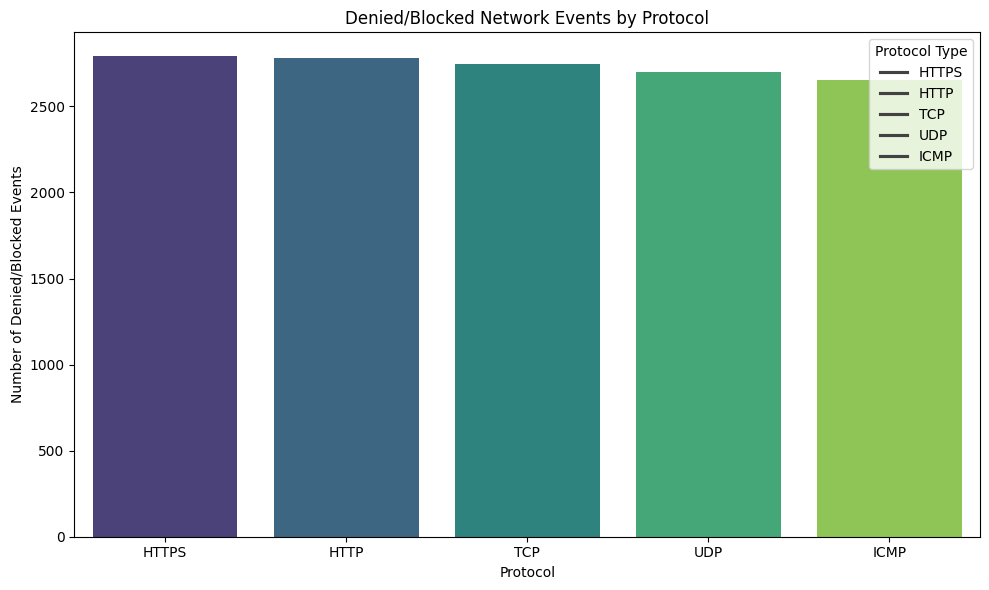

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=denied_actions_by_protocol.index, y=denied_actions_by_protocol.values, palette='viridis')

# Label the x-axis
plt.xlabel('Protocol')
# Label the y-axis
plt.ylabel('Number of Denied/Blocked Events')
# Set the title of the chart
plt.title('Denied/Blocked Network Events by Protocol')
# Add a legend (optional for a single series bar chart, but good practice if more categories were involved)
plt.legend(title='Protocol Type', labels=denied_actions_by_protocol.index)
# Display the plot
plt.tight_layout()
plt.show()
